# Market Making with PPO

**Execution environment**: local `uv run` on CPU. The small PPO MLP has no
meaningful GPU-heavy path.

This notebook implements a PPO market-making agent that learns to balance
spread capture against inventory risk through dynamic quote adjustment.

**Key Feature**: The simulation uses GARCH volatility parameters anchored to
real crypto market data to mimic volatility clustering in a stylized setting.

**Learning Outcomes**:
- LO3: Design a market-making agent that balances spread capture vs inventory risk
- LO8: Design reward functions incorporating risk management constraints

**Book Reference**: Chapter 21, Section 21.5.

**Prerequisites**: `calibration` and Chapter 18 on transaction costs.

In [1]:
"""Market Making with PPO - learn to balance spread capture against inventory risk through dynamic quote adjustment."""

# Core imports
import warnings

import numpy as np
import polars as pl
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=DeprecationWarning)


import plotly.graph_objects as go

# Calibration from real market data
from market_making_env import MarketMakingDynamics, MarketMakingEnv
from plotly.subplots import make_subplots
from rl_calibration import CryptoMarketCalibrator

# Stable-baselines3
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ML4T configuration
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
OUTPUT_DIR = get_output_dir(21, "market_making_actor_critic")

In [3]:
EPISODE_LENGTH = 500
TOTAL_TIMESTEPS = 300_000
EVAL_EPISODES = 20
INVENTORY_LIMIT = 100
LAMBDA_INVENTORY = 0.001
LEARNING_RATE = 3e-4
SEED = 314  # Reproducible training across re-runs
EXPORT_RESULTS = False

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration
config = {
    "episode_length": EPISODE_LENGTH,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_episodes": EVAL_EPISODES,
    "inventory_limit": INVENTORY_LIMIT,
    "lambda_inventory": LAMBDA_INVENTORY,  # Inventory penalty coefficient
    "learning_rate": LEARNING_RATE,
    "export_results": EXPORT_RESULTS,
}

print(f"Configuration: {config}")

SKEW_LEVELS = np.array([-1.0, 0.0, 1.0], dtype=np.float32)
SPREAD_MULTIPLIERS = np.array([0.8, 1.0, 1.25], dtype=np.float32)
RL_LABEL = "PPO"

Configuration: {'episode_length': 500, 'total_timesteps': 300000, 'eval_episodes': 20, 'inventory_limit': 100, 'lambda_inventory': 0.001, 'learning_rate': 0.0003, 'export_results': False}


## 0. Calibrate GARCH Parameters from Real Data

We fit GARCH(1,1) parameters from real crypto data to anchor the simulated
volatility process to observed market behavior.

In [6]:
# Calibrate from real BTC hourly data; calibration must succeed (no
# hardcoded fallback parameters).
print("Calibrating GARCH from real crypto data...")
calibrator = CryptoMarketCalibrator("BTCUSDT")
cal_params = calibrator.get_execution_env_params()

GARCH_ALPHA = cal_params.garch.alpha
GARCH_BETA = cal_params.garch.beta
GARCH_OMEGA = cal_params.garch.omega
UNCOND_VOL = cal_params.garch.unconditional_vol

if not all(np.isfinite([GARCH_ALPHA, GARCH_BETA, GARCH_OMEGA, UNCOND_VOL])):
    raise ValueError("Calibrated GARCH parameters contain NaN or Inf")

print(f"GARCH alpha: {GARCH_ALPHA:.4f}")
print(f"GARCH beta:  {GARCH_BETA:.4f}")
print(f"Uncond vol:  {UNCOND_VOL:.4f} ({UNCOND_VOL * 100:.2f}%)")

MM_DYNAMICS = MarketMakingDynamics(
    garch_omega=GARCH_OMEGA,
    garch_alpha=GARCH_ALPHA,
    garch_beta=GARCH_BETA,
    unconditional_vol=UNCOND_VOL,
    skew_levels=tuple(float(value) for value in SKEW_LEVELS),
    spread_multipliers=tuple(float(value) for value in SPREAD_MULTIPLIERS),
)

Calibrating GARCH from real crypto data...


GARCH alpha: 0.1281
GARCH beta:  0.8519
Uncond vol:  0.0067 (0.67%)


## 1. Market Making Environment

The `MarketMakingEnv` implements a Gymnasium environment where a market-making
agent posts bid and ask quotes, earns the spread when filled, and manages
inventory risk through dynamic quote adjustment.

**MDP Formulation**:

- **State** $s_t = (\hat{q}_t, \Delta p_t, \sigma_t, \delta_t, \tau_t, s_t^{\text{spread}})$:
  normalized inventory, mid-price change, GARCH volatility, order imbalance,
  time remaining, and current quoted spread
- **Action** $a_t \in \{-1, 0, 1\} \times \{0.8, 1.0, 1.25\}$: quote skew
  level and spread multiplier around the reservation price
- **Reward**: change in marked wealth minus an inventory penalty,
  $r_t = \Delta W_t - \lambda \, \hat{q}_t^2$

**Volatility dynamics** use calibrated GARCH(1,1) parameters from real crypto
data, anchoring the volatility process to observed clustering patterns:

$$\sigma_t^2 = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2$$

**Key building blocks** (all standalone): `generate_garch_market_data`,
`compute_quotes`, `fill_probability`, `simulate_fills`, `build_mm_obs`,
and `terminal_liquidation`, orchestrated by the environment's `reset` / `step`.

### GARCH Market Data Generator

Generates a synthetic price path with GARCH(1,1) volatility clustering
and mean-reverting order imbalance. Extracted as a standalone function
so it can be reused and tested independently.

## 2. Train PPO Agent

We train a Proximal Policy Optimization (PPO) agent to learn a spread-quoting
policy. PPO clips the policy-gradient ratio to prevent destructive updates,
which provides stable training for our discrete action space.

**Training pipeline**: environment factory $\rightarrow$ vectorized wrapper
$\rightarrow$ observation/reward normalization $\rightarrow$ PPO optimization.

### Environment Factory

Stable-Baselines3 requires a callable that returns a fresh environment instance.
We wrap this in `DummyVecEnv` for the vectorized API, then apply `VecNormalize`
to standardize observations and clip rewards for gradient stability.

In [7]:
def make_env(seed: int = 42):
    def _init():
        return MarketMakingEnv(
            episode_length=config["episode_length"],
            inventory_limit=config["inventory_limit"],
            lambda_inventory=config["lambda_inventory"],
            dynamics=MM_DYNAMICS,
            seed=seed,
        )

    return _init

In [8]:
env = DummyVecEnv([make_env(seed=SEED)])

# Normalize observations and rewards for stable training
# This prevents gradient explosion in longer training runs
env = VecNormalize(
    env,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0,
    clip_reward=10.0,
    gamma=0.99,
)

### Configure and Train PPO

The actor and critic each use a two-layer MLP with 64 hidden units.
PPO's clipped surrogate objective prevents catastrophic policy updates
from the highly variable market-making rewards.

In [9]:
learning_rate = config["learning_rate"]

policy_kwargs = dict(
    net_arch=dict(pi=[64, 64], vf=[64, 64]),
    ortho_init=True,
)

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=learning_rate,
    n_steps=256,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    policy_kwargs=policy_kwargs,
    device="cpu",  # Small MLP - CPU is faster than GPU for SB3
    verbose=0,
)

model.learn(total_timesteps=config["total_timesteps"])
print("\nTraining complete!")


Training complete!


## 3. Evaluate Agent

We compare the trained PPO agent against three reservation-price baselines
with fixed spread multipliers. This isolates whether the learned policy adds
value beyond an inventory-aware quoting heuristic with no extra skew.

### Action Encoding

Maps a (skew index, spread index) pair to a single integer for the
`Discrete(9)` action space expected by the environment.

In [10]:
def encode_action(skew_idx: int, spread_idx: int) -> int:
    return skew_idx * len(SPREAD_MULTIPLIERS) + spread_idx

### Episode Runner

Runs a single episode with either the RL agent or a fixed-spread baseline.
When using the RL model, observations are normalized via the `VecNormalize`
wrapper to match the distribution seen during training.

In [11]:
def run_episode(env_instance, model=None, fixed_action: int | None = None, vec_normalize=None):
    """Run episode with either RL agent or a deterministic quoting baseline.

    Args:
        env_instance: Raw MarketMakingEnv instance
        model: Trained PPO model (optional)
        fixed_action: Deterministic action for baseline (optional)
        vec_normalize: VecNormalize wrapper for observation normalization (optional)
    """
    obs, _ = env_instance.reset()
    done = False

    while not done:
        if model is not None:
            # Normalize observation using training stats
            if vec_normalize is not None:
                obs_normalized = vec_normalize.normalize_obs(np.array([obs]))
            else:
                obs_normalized = np.array([obs])
            action, _ = model.predict(obs_normalized, deterministic=True)
            action = action[0]
        else:
            action = fixed_action

        obs, reward, terminated, truncated, info = env_instance.step(action)
        done = terminated or truncated

    return {
        "final_wealth": float(info["wealth"]),
        "terminal_inventory": int(info["terminal_inventory"]),
        "n_trades": env_instance.n_trades,
        "history": env_instance.history,
    }

In [12]:
# Evaluate multiple episodes
print("\nEvaluating strategies...")

# Set VecNormalize to eval mode (don't update running stats)
env.training = False
env.norm_reward = False

baseline_actions = {
    "Reservation + Tight Spread": encode_action(skew_idx=1, spread_idx=0),
    "Reservation + Base Spread": encode_action(skew_idx=1, spread_idx=1),
    "Reservation + Wide Spread": encode_action(skew_idx=1, spread_idx=2),
}

results = {RL_LABEL: []} | {name: [] for name in baseline_actions}

for i in range(config["eval_episodes"]):
    test_env = MarketMakingEnv(
        episode_length=config["episode_length"],
        inventory_limit=config["inventory_limit"],
        lambda_inventory=config["lambda_inventory"],
        dynamics=MM_DYNAMICS,
        seed=1000 + i,
    )

    # PPO agent - pass VecNormalize for observation normalization
    test_env.reset(seed=1000 + i)
    results[RL_LABEL].append(run_episode(test_env, model=model, vec_normalize=env))

    # Deterministic reservation-price baselines
    for name, action in baseline_actions.items():
        test_env.reset(seed=1000 + i)
        results[name].append(run_episode(test_env, fixed_action=action))


Evaluating strategies...


## Market Making Strategy Comparison

In [13]:
summary_records = []
for name, runs in results.items():
    wealths = [r["final_wealth"] for r in runs]
    inventories = [abs(r["terminal_inventory"]) for r in runs]
    trades = [r["n_trades"] for r in runs]

    summary_records.append(
        {
            "strategy": name,
            "mean_final_wealth": float(np.mean(wealths)),
            "std_final_wealth": float(np.std(wealths)),
            "avg_abs_terminal_inventory": float(np.mean(inventories)),
            "avg_trades": float(np.mean(trades)),
        }
    )

summary = []
for row in summary_records:
    summary.append(
        {
            "Strategy": row["strategy"],
            "Mean Final Wealth": f"{row['mean_final_wealth']:.2f}",
            "Std Final Wealth": f"{row['std_final_wealth']:.2f}",
            "Avg |Terminal Inv|": f"{row['avg_abs_terminal_inventory']:.1f}",
            "Avg Trades": f"{row['avg_trades']:.0f}",
        }
    )

summary_df = pl.DataFrame(summary)
summary_df

Strategy,Mean Final Wealth,Std Final Wealth,Avg |Terminal Inv|,Avg Trades
str,str,str,str,str
"""PPO""","""10.49""","""77.24""","""1.1""","""154"""
"""Reservation + Tight Spread""","""11.42""","""15.78""","""0.8""","""111"""
"""Reservation + Base Spread""","""9.73""","""17.95""","""0.9""","""73"""
"""Reservation + Wide Spread""","""9.85""","""18.27""","""1.0""","""45"""


In [14]:
ppo_summary = next(row for row in summary_records if row["strategy"] == RL_LABEL)
baseline_summary = [row for row in summary_records if row["strategy"] != RL_LABEL]
baseline_mean_min = min(row["mean_final_wealth"] for row in baseline_summary)
baseline_mean_max = max(row["mean_final_wealth"] for row in baseline_summary)
baseline_std_min = min(row["std_final_wealth"] for row in baseline_summary)
baseline_std_max = max(row["std_final_wealth"] for row in baseline_summary)
display(
    Markdown(
        f"""
**Finding.** PPO earns mean liquidated wealth of {ppo_summary["mean_final_wealth"]:.1f} USD,
compared with {baseline_mean_min:.1f} to {baseline_mean_max:.1f} USD for the reservation-price
baselines. Its wealth standard deviation is {ppo_summary["std_final_wealth"]:.1f} USD, versus
{baseline_std_min:.1f} to {baseline_std_max:.1f} USD for the baselines. The learned policy's
signature in this run is dispersion, not clear mean dominance.
"""
    )
)


**Finding.** PPO earns mean liquidated wealth of 10.5 USD,
compared with 9.7 to 11.4 USD for the reservation-price
baselines. Its wealth standard deviation is 77.2 USD, versus
15.8 to 18.3 USD for the baselines. The learned policy's
signature in this run is dispersion, not clear mean dominance.


## 4. Visualize Learned Behavior

In [15]:
# Run single episode for visualization
viz_env = MarketMakingEnv(
    episode_length=config["episode_length"],
    inventory_limit=config["inventory_limit"],
    lambda_inventory=config["lambda_inventory"],
    dynamics=MM_DYNAMICS,
    seed=999,
)

viz_result = run_episode(viz_env, model=model, vec_normalize=env)
history = viz_result["history"]

In [16]:
# Build the PPO market-making behavior figure.
fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=["Inventory Over Time", "Quote Center Offset", "Liquidated Wealth"],
    vertical_spacing=0.12,
)

steps = [h["step"] for h in history]
inventory = [h["inventory"] for h in history]
quote_offset_bps = [h["quote_offset_bps"] for h in history]
wealth = [h["wealth"] for h in history]

fig.add_trace(
    go.Scatter(x=steps, y=inventory, name="Inventory", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

fig.add_trace(
    go.Scatter(
        x=steps,
        y=quote_offset_bps,
        name="Quote center offset (bps)",
        line=dict(color=COLORS["amber"]),
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

_ = fig.add_trace(
    go.Scatter(x=steps, y=wealth, name="Wealth", line=dict(color=COLORS["positive"])),
    row=3,
    col=1,
)

The shared layout makes the inventory, quote response, and terminal-wealth
panels comparable on one time axis.

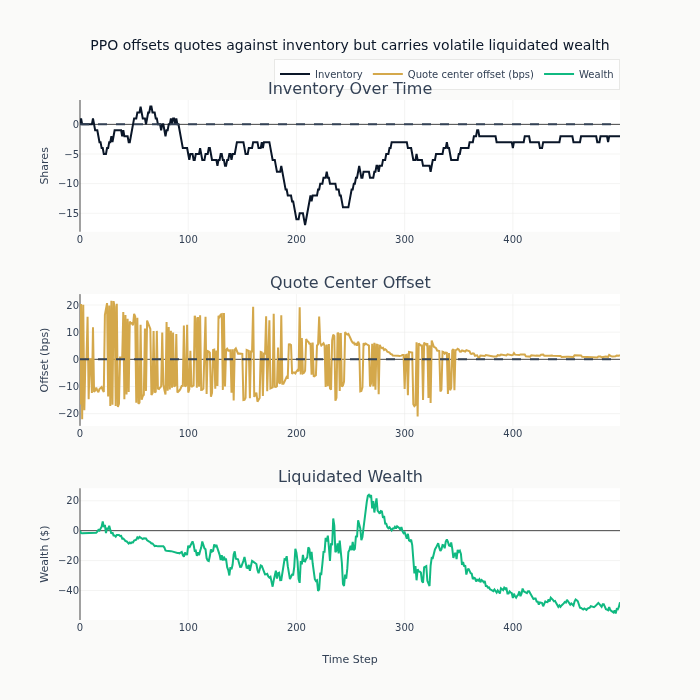

In [17]:
fig.update_layout(
    title="PPO offsets quotes against inventory but carries volatile liquidated wealth",
    height=700,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

fig.update_yaxes(title_text="Shares", row=1, col=1)
fig.update_yaxes(title_text="Offset (bps)", row=2, col=1)
fig.update_yaxes(title_text="Wealth ($)", row=3, col=1)
fig.update_xaxes(title_text="Time Step", row=3, col=1)

fig.show()

## 5. Spread vs Inventory Relationship

In [18]:
# Pool PPO evaluation histories and measure the learned quote-center shift
# as inventory varies.
policy_samples = [
    {"inventory": h["inventory"], "quote_offset_bps": h["quote_offset_bps"]}
    for run in results[RL_LABEL]
    for h in run["history"]
]
policy_df = pl.DataFrame(policy_samples)

inv_min = int(policy_df["inventory"].min())
inv_max = int(policy_df["inventory"].max())
if inv_min == inv_max:
    bin_edges = np.array([inv_min - 1, inv_max + 1], dtype=float)
else:
    bin_edges = np.linspace(inv_min, inv_max, 9)

bin_ids = np.digitize(policy_df["inventory"].to_numpy(), bin_edges[1:-1], right=False)
bin_labels = [
    f"{int(np.floor(bin_edges[i]))} to {int(np.ceil(bin_edges[i + 1]))}"
    for i in range(len(bin_edges) - 1)
]

grouped = []
offset_values = policy_df["quote_offset_bps"].to_numpy()
for idx, label in enumerate(bin_labels):
    mask = bin_ids == idx
    if np.any(mask):
        grouped.append({"inv_bin": label, "quote_offset_bps": float(offset_values[mask].mean())})

grouped_df = pl.DataFrame(grouped)

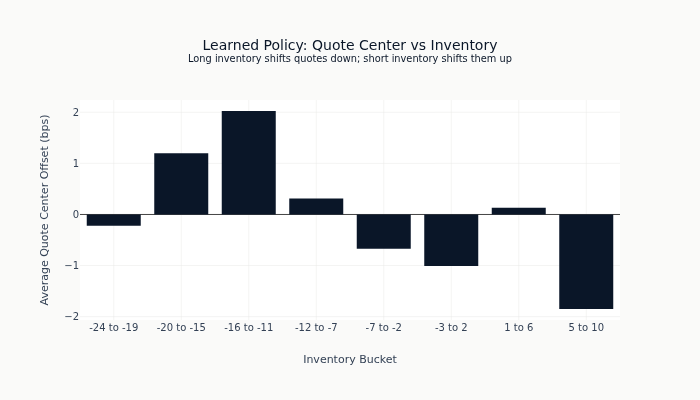

In [19]:
# Plot quote center offset vs inventory relationship
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=grouped_df["inv_bin"].to_list(),
        y=grouped_df["quote_offset_bps"].to_list(),
        marker_color=COLORS["blue"],
    )
)

fig.update_layout(
    title=(
        "Learned Policy: Quote Center vs Inventory"
        "<br><sup>Long inventory shifts quotes down; short inventory shifts them up</sup>"
    ),
    xaxis_title="Inventory Bucket",
    yaxis_title="Average Quote Center Offset (bps)",
    height=400,
)

fig.show()

In [20]:
if config["export_results"]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    run_rows = []
    for strategy, runs in results.items():
        for episode_idx, run in enumerate(runs):
            for row in run["history"]:
                run_rows.append(
                    {
                        "strategy": strategy,
                        "episode_idx": episode_idx,
                        **row,
                    }
                )

    viz_rows = [{"strategy": RL_LABEL, "episode_idx": 999, **row} for row in history]

    pl.DataFrame(run_rows).write_parquet(OUTPUT_DIR / "market_making_runs.parquet")
    pl.DataFrame(viz_rows).write_parquet(OUTPUT_DIR / "market_making_viz_history.parquet")
    pl.DataFrame(summary_records).write_parquet(OUTPUT_DIR / "market_making_summary.parquet")
    print(f"\nResults saved to {OUTPUT_DIR}")

## Key Takeaways

The comparison uses one common held-out seed set and freezes the training normalization state
during evaluation, so differences reflect policies rather than evaluation-state drift.

In [21]:
ppo_trades = ppo_summary["avg_trades"]
baseline_trade_min = min(row["avg_trades"] for row in baseline_summary)
baseline_trade_max = max(row["avg_trades"] for row in baseline_summary)
display(
    Markdown(
        f"""
The PPO policy shifts its quote center against inventory, reproducing the qualitative
inventory-control mechanism. It averages {ppo_trades:.0f} trades per episode, compared with
{baseline_trade_min:.0f} to {baseline_trade_max:.0f} for the fixed-spread baselines. Performance is
measured after terminal liquidation, so every strategy uses the same inventory and mark-to-market
convention.

The learned policy jointly chooses skew and spread width, but it does not establish mean dominance
over the reservation-price rules. It remains a simulator policy rather than a closed-form
reproduction of Avellaneda-Stoikov.

**Next**: See `deep_hedging_pfhedge` for option hedging with tail-risk objectives. Section 21.5
develops the market-making interpretation.
"""
    )
)


The PPO policy shifts its quote center against inventory, reproducing the qualitative
inventory-control mechanism. It averages 154 trades per episode, compared with
45 to 111 for the fixed-spread baselines. Performance is
measured after terminal liquidation, so every strategy uses the same inventory and mark-to-market
convention.

The learned policy jointly chooses skew and spread width, but it does not establish mean dominance
over the reservation-price rules. It remains a simulator policy rather than a closed-form
reproduction of Avellaneda-Stoikov.

**Next**: See `deep_hedging_pfhedge` for option hedging with tail-risk objectives. Section 21.5
develops the market-making interpretation.
